In [1]:
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
import torch
from torch import nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import torch_geometric as tg
from torch.nn import functional as F
from captum.attr import IntegratedGradients

from cardioverse.configs.gnn_config import GNNModelConfig, TrainingConfig
from cardioverse.configs.fusion_config import FusionModelConfig, FusionTrainingConfig
from cardioverse.models.linet import LiNetModel
from cardioverse.models.fusion import GNNIntegrativeModel
from cardioverse.training.gnn_trainer import GNNTrainer
from cardioverse.training.fusion_trainer import GNNFusionTrainer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle

from tqdm import tqdm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

## Load the data 

In [18]:
# Load gene level data
X = pd.read_csv("../data/gene_level_data/X.csv", index_col=0)
edge_index = np.load("../data/gene_level_data/edge_index.npy")

# get feature names
genes = list(X.columns)

# Load metadata
drug_metadata = pd.read_csv("../data/metadata/drug_metadata.csv")

print(f"Data shape: {X.shape}")
print(f"Samples: {X.index.tolist()[:5]}...")
print(f"Genes: {genes[:5]}...")

Data shape: (299, 916)
Samples: ['MSN01:afatinib', 'MSN02:afatinib', 'MSN05:afatinib', 'MSN06:afatinib', 'MSN08:afatinib']...
Genes: ['GNB1', 'PRKCZ', 'PIK3CD', 'MTOR', 'AGTRAP']...


## Set up train/val splits for training and validation

In [31]:
# Set up labels from metadata
drug_tox = drug_metadata.set_index("Drug name")["Is_cardiotoxic"]
drug_tox = drug_tox.map({"Yes": 1, "No": 0, "ND": -1})
drug_tox = drug_tox[drug_tox != -1]

# Get sample names from data index
sample_names = X.index.tolist()

# Filter to samples with labels
mask = [name.split(":")[1] in drug_tox.index for name in sample_names]
X = X.loc[mask]

# set up labels
sample_ids = list(X.index)
y = np.array([drug_tox[name.split(":")[-1]] for name in sample_ids]).astype(np.int64)

# split by drugs 
unique_drugs = list(drug_tox.index)
drug_labels = list(drug_tox.values)
train_drugs, val_drugs, _, _ = train_test_split(
    unique_drugs, drug_labels, test_size=0.3, stratify=drug_labels, random_state=0
)
train_mask = [v.split(":")[-1] in train_drugs for v in X.index]
val_mask = [v.split(":")[-1] in val_drugs for v in X.index]
X_train = X.loc[train_mask].values
X_val = X.loc[val_mask].values
train_sample_ids = X.loc[train_mask].index
val_sample_ids = X.loc[val_mask].index
y_train = y[train_mask]
y_val = y[val_mask]
print(f'Train samples: {len(X_train)}')
print(f'Val samples: {len(X_val)}')

Train samples: 125
Val samples: 53


## Set up and train the model 

In [32]:
# Training hyperparameters
num_layers = 3
hidden_dim = 100
dropout = 0.5
batch_size = 64
nepochs = 250
lr = 1e-5
lmbda_l1 = 1e-3
lmbda_l2 = 1e-3

# Create torch datasets
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
train_dataset = TensorDataset(
    X_train, torch.from_numpy(y_train).long(), torch.arange(len(X_train))
)
val_dataset = TensorDataset(
    X_val, torch.from_numpy(y_val).long(), torch.arange(len(X_val))
)

# Set up configs, model and trainer
model_config = GNNModelConfig(
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    num_nodes=X_train.shape[1],
)
train_config = TrainingConfig(
    batch_size=batch_size, nepochs=nepochs, lr=lr, lmbda_l1=lmbda_l1, lmbda_l2=lmbda_l2
                        )
model = LiNetModel(model_config)
optimizer = optim.Adam(model.parameters(), lr=train_config.lr)
trainer = GNNTrainer(model, optimizer, torch.from_numpy(edge_index).long())

# fit 
history = trainer.fit(train_dataset, val_dataset, train_config)

# Store the best model
model = deepcopy(trainer.model).to("cpu")

[ Epoch 1 ] : loss: 0.710; val_loss: 0.703; acc: 0.508; val_acc: 0.500; f1: 0.357; val_f1: 0.338; auroc: 0.416; val_auroc: 0.519
[ Epoch 50 ] : loss: 0.608; val_loss: 0.595; acc: 0.639; val_acc: 0.788; f1: 0.590; val_f1: 0.781; auroc: 0.664; val_auroc: 0.909
[ Epoch 100 ] : loss: 0.600; val_loss: 0.550; acc: 0.648; val_acc: 0.808; f1: 0.602; val_f1: 0.803; auroc: 0.711; val_auroc: 0.892
[ Epoch 150 ] : loss: 0.591; val_loss: 0.519; acc: 0.648; val_acc: 0.827; f1: 0.607; val_f1: 0.824; auroc: 0.739; val_auroc: 0.954
[ Epoch 200 ] : loss: 0.588; val_loss: 0.508; acc: 0.657; val_acc: 0.846; f1: 0.623; val_f1: 0.845; auroc: 0.721; val_auroc: 0.957
[ Epoch 250 ] : loss: 0.587; val_loss: 0.504; acc: 0.640; val_acc: 0.847; f1: 0.601; val_f1: 0.846; auroc: 0.742; val_auroc: 0.960


## Check validation curves 

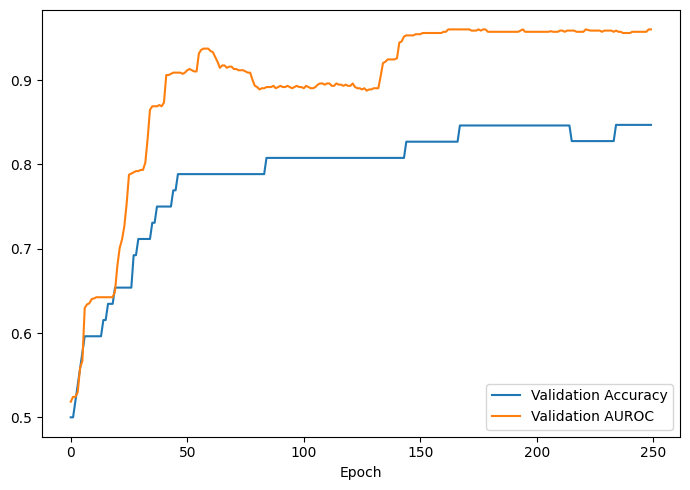

In [33]:
plt.figure(figsize=(7, 5))
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.plot(history['val_auroc'], label='Validation AUROC')
plt.legend()
plt.xlabel("Epoch")
plt.tight_layout()

## Check confusion matrix 

<Axes: >

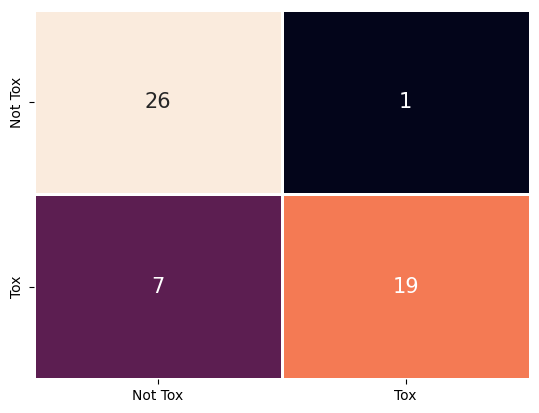

In [34]:
yval_true, yval_pred, val_ids = [], [], []
for batch in DataLoader(val_dataset, batch_size=32):
    x, y, ids = batch
    data_list = [tg.data.Data(x=x[i].unsqueeze(1), y=y[i].unsqueeze(0), edge_index=torch.from_numpy(edge_index).long()) for i in range(len(x))]
    graph_batch = tg.data.Batch.from_data_list(data_list)
    logits, _ = model(graph_batch.x, edge_index=graph_batch.edge_index, batch=graph_batch.batch)
    yval_pred += list(F.softmax(logits, dim=1).detach().cpu().numpy().argmax(1))
    yval_true += list(y.detach().cpu().numpy())
    val_ids += list(ids.detach().cpu().numpy())
valpred_df = pd.DataFrame(index=val_sample_ids[val_ids], data={"ytrue":yval_true, "ypred":yval_pred})

confmat_val = confusion_matrix(yval_true, yval_pred)
confmat_val = pd.DataFrame(confmat_val, index=["Not Tox", "Tox"], columns=["Not Tox", "Tox"])
sns.heatmap(confmat_val, cbar=False, linewidth=2., annot=True, annot_kws={"fontsize":15}, fmt="d")

## Model explanations 

### Get integrated gradients score

In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def model_forward(x):
    data_list = [tg.data.Data(x=x[i].unsqueeze(1), edge_index=torch.from_numpy(edge_index).long()) for i in range(len(x))]
    graph_batch = tg.data.Batch.from_data_list(data_list)
    graph_batch = graph_batch.to(device)
    return model(graph_batch.x, edge_index=graph_batch.edge_index, batch=graph_batch.batch)[0]

ig = IntegratedGradients(model_forward,) 
res, ids = [], []
for (x_input, i) in tqdm(zip(val_dataset.tensors[0], val_dataset.tensors[2]), total=len(val_dataset)):
    ids.append(i.detach().cpu().numpy().item())
    x_input.requires_grad = True
    _res = ig.attribute(x_input.unsqueeze(0), target=1).detach().cpu().numpy()
    res.append(_res)
res = np.vstack(res)
igdf = pd.DataFrame(res, index=ids, columns=genes)
igdf.index = val_sample_ids[igdf.index]

# get true positive IG scores 
correct_tox_samids = valpred_df[(valpred_df.ytrue==1) & (valpred_df.ytrue==valpred_df.ypred)].index.to_list()
ig_tox = igdf.loc[correct_tox_samids]

# # get true negative IG scores 
correct_notox_samids = valpred_df[(valpred_df.ytrue==0) & (valpred_df.ytrue==valpred_df.ypred)].index.to_list()
ig_notox = igdf.loc[correct_notox_samids]

100%|████████████████████████████████████████████████████████| 53/53 [00:01<00:00, 40.76it/s]


### Do differential attribution analysis and identify significant hits (features)

In [58]:
# multiple hyopthesis testing for identifying important reactions 
pvals = []
for gene in ig_tox.columns:
    stat, p = mannwhitneyu(ig_tox[gene], ig_notox[gene], alternative='two-sided')
    pvals.append(p)
reject, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')

# Compile results
infr_df = pd.DataFrame(
                        {
                        'gene': ig_notox.columns,
                        'pval': pvals,
                        'pval_adj': pvals_adj,
                        '-log10padj':-np.log10(pvals_adj),
                        'reject': reject,
                        'mean_Tox': ig_tox.mean(),
                        'mean_NoTox': ig_notox.mean(),
                        'mean_diff': ig_tox.mean() - ig_notox.mean(),
                        }
                    ).set_index('gene').sort_values('pval_adj')
top20_df = infr_df.head(20)

In [59]:
top20_df

,pval,pval_adj,-log10padj,reject,mean_Tox,mean_NoTox,mean_diff
gene,,,,,,,
ACOX1,1.925256e-08,0.000005,5.298035,True,-0.004240,4.129912e-07,-0.004241
PDGFRA,1.474138e-08,0.000005,5.298035,True,0.010346,2.177836e-06,0.010344
SLC8A1,1.474138e-08,0.000005,5.298035,True,-0.019692,3.158157e-07,-0.019692
ACVR1B,2.198513e-08,0.000005,5.298035,True,0.044618,-1.099746e-06,0.044619
BTRC,4.039877e-07,0.000053,4.276834,True,0.024264,-3.720228e-06,0.024267
NDRG1,4.039877e-07,0.000053,4.276834,True,0.005543,-1.924750e-06,0.005545
HLA-E,3.579710e-07,0.000053,4.276834,True,0.005465,-2.661577e-06,0.005468
SKP1,5.137392e-07,0.000059,4.230452,True,-0.005479,-2.659332e-06,-0.005477
ADCY6,5.788914e-07,0.000059,4.229750,True,0.001627,3.895375e-06,0.001623
